In [ ]:
# !pip install timm
import torch
import torch.nn as nn
import torchsummary as summary
import numpy as np
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.models as models
from torch.utils.data import DataLoader, random_split
# import timm

In [ ]:
class Stem(nn.Module): # Reduce size to 1/4 of initial
    def __init__(self):
        super(Stem, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=2,padding=1)
        self.batchNorm1 = nn.BatchNorm2d(64)
        self.reLU1= nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3,stride=2,padding=1)
        self.batchNorm2= nn.BatchNorm2d(64)
        self.reLU2 = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv1(x)
        x = self.batchNorm1(x)
        x = self.reLU1(x)
        x = self.conv2(x)
        x = self.batchNorm2(x)
        x = self.reLU2(x)
        return x

class Bottleneck(nn.Module):
    def __init__(self,in_channels,out_channels=256):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=1)
        self.batchNorm1 = nn.BatchNorm2d(64)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3,stride=1, padding=1)
        self.batchNorm2 = nn.BatchNorm2d(64)
        self.relu2=nn.ReLU(inplace=True)
        self.conv3 = nn.Conv2d(64, out_channels, kernel_size=1)
        self.batchNorm3 = nn.BatchNorm2d(out_channels)
        self.downsample=nn.Sequential()

        self.downsample = nn.Sequential()
        if in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm2d(out_channels)
            )
        self.relu3=nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x
        x = self.conv1(x)
        x = self.batchNorm1(x)
        x=self.relu1(x)
        x = self.conv2(x)
        x = self.batchNorm2(x)
        x=self.relu2(x)
        x = self.conv3(x)
        x = self.batchNorm3(x)

        identity = self.downsample(identity)
        x += identity
        x=self.relu3(x)
        return x

class Stage1(nn.Module):
    def __init__(self):
        super(Stage1, self).__init__()
        self.unit1=Bottleneck(64,256)
        self.unit2=Bottleneck(256,256)
        self.unit3=Bottleneck(256,256)
        self.unit4=Bottleneck(256,256)

    def forward(self, x):
        x=self.unit1(x)
        x=self.unit2(x)
        x=self.unit3(x)
        x=self.unit4(x)
        return x

class Trans1(nn.Module):
    def __init__(self,c):
        super(Trans1, self).__init__()
        self.layer1=nn.Sequential(
            nn.Conv2d(256,c,kernel_size=3,padding=1),
            nn.BatchNorm2d(c),
            nn.ReLU(inplace=True)
        )

        self.layer2=nn.Sequential(
            nn.Conv2d(256,2*c,kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(2*c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        out = [self.layer1(x), self.layer2(x)]
        return out

class ResUnit(nn.Module): # Pre-activation Residual Unit
    def __init__(self,in_channels,out_channels):
        super(ResUnit, self).__init__()
        self.bn1=nn.BatchNorm2d(out_channels)
        self.relu1=nn.ReLU(inplace=True)
        self.conv1=nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn2=nn.BatchNorm2d(out_channels)
        self.relu2=nn.ReLU(inplace=True)
        self.conv2=nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)

        self.downsample=nn.Sequential()
        if in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity=x
        x=self.bn1(x)
        x=self.relu1(x)
        x=self.conv1(x)
        x=self.bn2(x)
        x=self.relu2(x)
        x=self.conv2(x)


        identity=self.downsample(identity)
        x+=identity
        return x

class M_Block(nn.Module): # Modularised Block
    def __init__(self,c,stage,trans):
        super(M_Block, self).__init__()
        self.branches=nn.ModuleList()
        if trans==True:
            self.trans=1
        else:
            self.trans=0
        for i in range(stage):
            self.branches.append(nn.Sequential(
                ResUnit(c*(2**i),c*(2**i)),
                ResUnit(c*(2**i),c*(2**i)),
                ResUnit(c*(2**i),c*(2**i)),
                ResUnit(c*(2**i),c*(2**i))
            ))

        self.fusion=nn.ModuleList()
        for i in range(stage+self.trans):
            branch=nn.ModuleList()
            for j in range(stage):
                if i==j:
                    branch.append(nn.Sequential())
                elif i<j:
                    branch.append(nn.Sequential(
                        nn.Conv2d(c*(2**j),c*(2**i),kernel_size=1),
                        nn.BatchNorm2d(c*(2**i)),
                        nn.Upsample(scale_factor=2**(j-i), mode='nearest')
                    ))
                else:
                    downsample=[]
                    for k in range(i-j):
                        downsample.append(nn.Sequential(
                            nn.Conv2d(c*(2**(j+k)),c*(2**(j+k+1)),kernel_size=3,stride=2,padding=1),
                            nn.BatchNorm2d(c*(2**(j+k+1)))
                        ))
                    downsample.append(nn.ReLU(inplace=True))

                    branch.append(nn.Sequential(*downsample))
            self.fusion.append(branch)



    def forward(self, x):
        out=[]

        for i in range(len(self.branches)):
            out.append(self.branches[i](x[i]))

        out_fusion=[]

        for i in range(len(self.fusion)):
            temp=[]
            for j in range(len(self.fusion[i])):
                temp.append(self.fusion[i][j](out[j]))

            out_fusion.append(sum(temp))

        for i in range(len(out_fusion)):
            out_fusion[i]=nn.ReLU(inplace=True)(out_fusion[i])
        return out_fusion


class Stage2(nn.Module):
    def __init__(self, c):
        super(Stage2, self).__init__()
        self.m_block = M_Block(c,stage=2,trans=True)

    def forward(self, x):
        x=self.m_block(x)
        return x

class Stage3(nn.Module):
    def __init__(self, c):
        super(Stage3, self).__init__()
        self.m_block1 = M_Block(c,stage=3,trans=False)
        self.m_block2 = M_Block(c,stage=3,trans=False)
        self.m_block3 = M_Block(c,stage=3,trans=False)
        self.m_block4 = M_Block(c,stage=3,trans=True)

    def forward(self, x):
        x=self.m_block1(x)
        x=self.m_block2(x)
        x=self.m_block3(x)
        x=self.m_block4(x)
        return x

class Stage4(nn.Module):
    def __init__(self, c):
        super(Stage4, self).__init__()
        self.m_block1 = M_Block(c,stage=4,trans=False)
        self.m_block2 = M_Block(c,stage=4,trans=False)
        self.m_block3 = M_Block(c,stage=4,trans=False)

    def forward(self, x):
        x=self.m_block1(x)
        x=self.m_block2(x)
        x=self.m_block3(x)
        return x

class Head(nn.Module):
    def __init__(self,c):
        super(Head, self).__init__()
        self.branches=nn.ModuleList()
        for i in range(4):
            self.branches.append(nn.Sequential(
                nn.Conv2d((2**i)*c,(2**i)*32,kernel_size=1,stride=1),
                nn.BatchNorm2d((2**i)*32),
                nn.ReLU(inplace=True),
                nn.Conv2d((2**i)*32,(2**i)*32,kernel_size=3,stride=1,padding=1),
                nn.BatchNorm2d((2**i)*32),
                nn.ReLU(inplace=True),
                nn.Conv2d((2**i)*32,(2**i)*128,kernel_size=1,stride=1),
                nn.BatchNorm2d((2**i)*128),
                nn.ReLU(inplace=True)
            ))

        self.downsamples=nn.ModuleList()
        for i in range(4):
            self.downsamples.append(nn.Sequential(
                nn.Conv2d((2**i)*c,(2**i)*128,kernel_size=1,stride=1),
                nn.BatchNorm2d((2**i)*128),

            ))

        self.merges=nn.ModuleList()
        for i in range(3):
            self.merges.append(nn.Sequential(
                nn.Conv2d((2**i)*128,(2**i)*256,kernel_size=3,stride=2,padding=1),
                nn.BatchNorm2d((2**i)*256),
                nn.ReLU(inplace=True)
            ))

        self.final=nn.Sequential(
            nn.Conv2d(1024,2048,kernel_size=1,stride=1),
            nn.BatchNorm2d(2048),
            nn.ReLU(inplace=True)
        )

        self.fc=nn.Linear(2048,100)


    def forward(self, x):
        out=[]

        for i in range(len(self.branches)):
            # print(x[i].size())
            # print(self.branches[i](x[i]).size(),self.downsamples[i](x[i]).size())
            # print(i)
            out.append(self.branches[i](x[i])+self.downsamples[i](x[i]))
        y=self.merges[0](out[0])
        # print("done1")
        # print("out1",out[1].size(),y.size())
        y=self.merges[1](out[1]+y)
        # print("done2")
        # print("out2",out[2].size(),y.size())
        y=self.merges[2](out[2]+y)
        # print("done3")
        # print("out3",out[3].size(),y.size())
        y=self.final(out[3]+y)
        # print("done4")
        y=nn.AvgPool2d(kernel_size=y.size()[2:])(y)
        # print("done5")
        y_flattened = y.view(y.size(0), -1)
        # print("done6")
        preds=self.fc(y_flattened)

        return preds


class HRNet(nn.Module):
    def __init__(self, c=18):
        super(HRNet, self).__init__()
        self.stem = Stem()
        self.stage1 = Stage1()
        self.trans1= Trans1(c)
        self.stage2=Stage2(c)
        self.stage3=Stage3(c)
        self.stage4=Stage4(c)
        self.head=Head(c)


    def forward(self, x):
        x = self.stem(x)
        x=self.stage1(x)
        x= self.trans1(x)
        x=self.stage2(x)
        x=self.stage3(x)
        x=self.stage4(x)
        x=self.head(x)
        return x



class EarlyStopping:
    def __init__(self, patience=7, verbose=False, delta=0):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

In [ ]:

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print("Device",device)
# model = HRNet(c=30).to(device)

# model = timm.create_model('hrnet_w30', pretrained=False, num_classes=100).to(device)
# print(model)


Device cuda


In [ ]:
mymodel=HRNet(c=30).to(device)
# print(mymodel)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download and load the CIFAR100 dataset
trainset = datasets.CIFAR100(root='./data', train=True,
                             download=True, transform=transform)

# Split the trainset into train and validation sets
num_train = len(trainset)
indices = list(range(num_train))
split = int(0.8 * num_train)  # 80% for training

train_subset, val_subset = random_split(trainset, [split, num_train - split])

trainloader = DataLoader(train_subset, batch_size=16, shuffle=True, num_workers=2)
valloader = DataLoader(val_subset, batch_size=16, shuffle=False, num_workers=2)

# Load the test dataset
testset = datasets.CIFAR100(root='./data', train=False,
                            download=True, transform=transform)
testloader = DataLoader(testset, batch_size=16, shuffle=False, num_workers=2)

# Get the list of classes
classes = trainset.classes

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(mymodel.parameters(), lr=0.005, momentum=0.9)

print("Data loaders prepared: Train, Validation, and Test")

100%|██████████| 169001437/169001437 [00:13<00:00, 12604807.11it/s]


Extracting ./data/cifar-100-python.tar.gz to ./data
Files already downloaded and verified
Data loaders prepared: Train, Validation, and Test


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
def save_checkpoint(epoch, model, optimizer, filename):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    }
    torch.save(checkpoint, filename)



In [ ]:
def load_checkpoint(filename, model, optimizer, device):
    # Load the checkpoint file
    checkpoint = torch.load(filename, map_location=device)

    # Restore the model and optimizer state
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    # Return the epoch number if needed
    return checkpoint['epoch']



In [ ]:
early_stopping = EarlyStopping(patience=2, verbose=True)

# Track loss for plotting
train_losses = []
val_losses = []

for epoch in range(25):  # limited epoch count for demonstration
    running_loss = 0.0
    total_samples = 0  # To count the total number of samples processed
    mymodel.train()  # Ensure the model is in training mode
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = mymodel(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        total_samples += inputs.size(0)
        if i % 1000 == 999:  # Print every 500 mini-batches
            current_loss = running_loss / total_samples  # Calculate current average loss
            print('[%d, %5d] loss: %.3f' % (epoch + 1, i + 1, current_loss))
            running_loss = 0.0
            total_samples = 0  # Reset counters

    # Calculate average training loss
    if total_samples > 0:  # Check to prevent division by zero
        train_loss = running_loss / total_samples
        train_losses.append(train_loss)

    # Validation phase
    mymodel.eval()
    val_running_loss = 0.0
    val_total_samples = 0
    with torch.no_grad():
        for data in valloader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = mymodel(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * inputs.size(0)
            val_total_samples += inputs.size(0)



    save_checkpoint(epoch, mymodel, optimizer, '/content/drive/MyDrive/Colab Notebooks/checkpoint_c30_early_stop1.pth')
    print('Saved checkpoint with epoch: ' , epoch)


    if val_total_samples > 0:
        val_loss = val_running_loss / val_total_samples
        val_losses.append(val_loss)

    print(f'Epoch {epoch + 1} - Training Loss: {train_loss:.3f}, Validation Loss: {val_loss:.3f}')

    # Early stopping based on validation loss
    early_stopping(val_loss, mymodel)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break
print('Finished Training')

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


[1,  1000] loss: 4.243
[1,  2000] loss: 3.833
Saved checkpoint with epoch:  0
Epoch 1 - Training Loss: 3.616, Validation Loss: 3.522
[2,  1000] loss: 3.431
[2,  2000] loss: 3.235
Saved checkpoint with epoch:  1
Epoch 2 - Training Loss: 3.098, Validation Loss: 2.963
[3,  1000] loss: 2.865
[3,  2000] loss: 2.672
Saved checkpoint with epoch:  2
Epoch 3 - Training Loss: 2.551, Validation Loss: 3.855
EarlyStopping counter: 1 out of 2
[4,  1000] loss: 2.351
[4,  2000] loss: 2.268
Saved checkpoint with epoch:  3
Epoch 4 - Training Loss: 2.210, Validation Loss: 2.150
[5,  1000] loss: 1.957
[5,  2000] loss: 1.922
Saved checkpoint with epoch:  4
Epoch 5 - Training Loss: 1.890, Validation Loss: 2.122
[6,  1000] loss: 1.630
[6,  2000] loss: 1.629
Saved checkpoint with epoch:  5
Epoch 6 - Training Loss: 1.629, Validation Loss: 1.950
[7,  1000] loss: 1.323
[7,  2000] loss: 1.387
Saved checkpoint with epoch:  6
Epoch 7 - Training Loss: 1.407, Validation Loss: 2.167
EarlyStopping counter: 1 out of 2
[

In [ ]:
save_checkpoint(5, mymodel, optimizer, '/content/drive/MyDrive/Colab Notebooks/checkpoint_c30_early_stop1.pth')
print('Finished Training')

Finished Training


In [ ]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = mymodel(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (100 * correct / total))

Accuracy of the network on the 10000 test images: 53 %


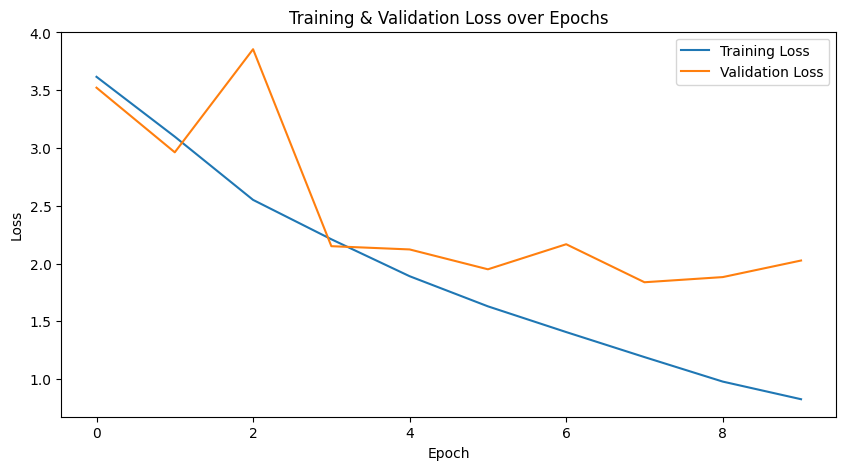

In [ ]:

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training & Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Assuming HRNet and device are defined, and your model has been initialized
# You may need to redefine your model architecture if it's not available in the scopedevice = 'cuda' if torch.cuda.is_available() else 'cpu'
mymodel = HRNet(c=2).to(device)
optimizer = optim.SGD(mymodel.parameters(), lr=0.005, momentum=0.9)

# Load the checkpoint; specify the path to your checkpoint file
last_epoch = load_checkpoint('./checkpoint_c2_early_stop.pth', mymodel, optimizer, device)
# Resume training

In [ ]:
for epoch in range(last_epoch, 25):  # limited epoch count for demonstration
    running_loss = 0.0
    mymodel.train()  # Ensure the model is in training mode
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = mymodel(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 500 == 499:  # Print every 500 mini-batches
            print('[%d, %5d] loss: %.3f' % (epoch + 1, i + 1, running_loss / 500))
            running_loss = 0.0

    # Calculate average training loss
    train_loss = running_loss / len(trainloader)
    train_losses.append(train_loss)

    # Validation phase
    mymodel.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for data in valloader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = mymodel(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
    val_loss = val_running_loss / len(valloader)
    val_losses.append(val_loss)

    print(f'Epoch {epoch + 1} Training Loss: {train_loss:.3f}, Validation Loss: {val_loss:.3f}')

    # Early stopping based on validation loss
    early_stopping(val_loss, mymodel)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

[26,   500] loss: 0.008
[26,  1000] loss: 0.009
[26,  1500] loss: 0.008
[26,  2000] loss: 0.008
[26,  2500] loss: 0.012
[26,  3000] loss: 0.014
[27,   500] loss: 0.009
[27,  1000] loss: 0.009
[27,  1500] loss: 0.012
[27,  2000] loss: 0.009
[27,  2500] loss: 0.011
[27,  3000] loss: 0.011
[28,   500] loss: 0.009
[28,  1000] loss: 0.007
[28,  1500] loss: 0.010
[28,  2000] loss: 0.010
[28,  2500] loss: 0.012
[28,  3000] loss: 0.014
[29,   500] loss: 0.008
[29,  1000] loss: 0.008
[29,  1500] loss: 0.006
[29,  2000] loss: 0.008
[29,  2500] loss: 0.008
[29,  3000] loss: 0.007
[30,   500] loss: 0.006
[30,  1000] loss: 0.004
[30,  1500] loss: 0.003
[30,  2000] loss: 0.009
[30,  2500] loss: 0.008
[30,  3000] loss: 0.007
[31,   500] loss: 0.006
[31,  1000] loss: 0.004
[31,  1500] loss: 0.004
[31,  2000] loss: 0.006
[31,  2500] loss: 0.006
[31,  3000] loss: 0.006
[32,   500] loss: 0.003
[32,  1000] loss: 0.003
[32,  1500] loss: 0.004
[32,  2000] loss: 0.004
[32,  2500] loss: 0.005
[32,  3000] loss

In [ ]:
save_checkpoint(epoch, mymodel, optimizer, 'checkpoint_c2_early_stop2.pth')

In [ ]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = mymodel(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (100 * correct / total))

Accuracy of the network on the 10000 test images: 60 %
